## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201 Sec 007: Quiz 4 (Spring 2026)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**100**</font> possible on this quiz. **If you get stuck on a particular question, do your best to provide what your solution *might* look like for later parts of the quiz in order to create opportunities for partial credit.**

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (40 points)

&#9989;&nbsp; **Question 1.1 (20 points)**: In this question, we are going to model a simple biochemical system of two genes $A$ and $B$ that repress each other's expression. We will model the system with two simple ODEs:

$$ \frac{dA}{dt} = \frac{p}{1 + B^q} - rA $$
$$ \frac{dB}{dt} = \frac{p}{1 + A^q} - rB $$

Here, variables $A$ and $B$ represent the level of expression of the two genes, respectively. The parameter $p$ represents the maximum expression rate of each gene, $q$ is the Hill coefficient (cooperativity), and $r$ is the degradation rate of each gene product.

You have to solve this system using `solve_ivp`. Assume the following initial conditions:
Level of gene $A$ = 10.0 (that is, $A(0) = 10.0$)\
Level of gene $B$ = 2.0 (that is, $B(0) = 2.0$)

Use the following values for the parameters $p$, $q$, and $r$:
$p$ = 10.0\
$q$ = 2.0\
$r$ = 1.0

Evolve the model for 50 time units using a timestep of $\Delta t = 0.1$.

**Code you need to write to solve this problem**:
* A function that takes in a time value together with the current values of $A$ and $B$ and **returns** the derivatives $\frac{dA}{dt}$ and $\frac{dB}{dt}$. This will be the derivatives function that `solve_ivp` needs.
* Variables for storing the initial conditions $A_0$ and $B_0$.
* A variable that stores all of the times for which you want to solve the system of ODEs. You can generate these times using `np.arange()`. The times should match the time range and timestep size specified above.
* Code that calls `solve_ivp` using the appropriate arguments and stores the result.
* Code that unpacks the solution so that you can plot it.

**Note**: you will not need the `args` argument for `solve_ivp` in this problem because all model parameters are already provided directly in the ODEs above.

In [1]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here

In [4]:
### ANSWER ###

from scipy.integrate import solve_ivp
import numpy as np

p = 10.0
q = 2.0
r = 1.0

def derivs(t, state):
    A, B = state
    dA_dt = p / (1 + B**q) - r * A
    dB_dt = p / (1 + A**q) - r * B
    return dA_dt, dB_dt

A0 = 10.0
B0 = 2.0
ICs = [A0, B0]

t = np.arange(0, 50, 0.1)
sol = solve_ivp(derivs, (t[0], t[-1]), ICs, t_eval=t)

A = sol.y[0]
B = sol.y[1]

&#9989;&nbsp; **Question 1.2 (10 points)**:
Now that you have a solution to the model, make a single plot that displays the evolution of both variables $A$ and $B$ as a function of time. Each line should be a different color and your plot should contain an $x$-axis label, a $y$-axis label, a legend, and a title.

If all goes well, you should end up with something that looks like this:

<img src="https://i.ibb.co/Ngr103d1/Gene-Tog-Switch-fig.png" alt="Gene-Tog-Switch-fig" border="0">

In [ ]:
# Put your code here

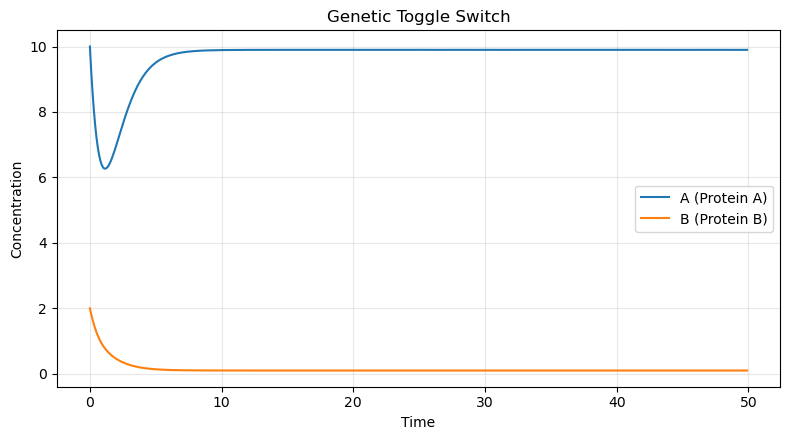

In [5]:
### ANSWER ###

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.plot(sol.t, A, label="A (Protein A)")
plt.plot(sol.t, B, label="B (Protein B)")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Genetic Toggle Switch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### &#9989;&nbsp; **Question 1.3 (10 points)**

Based on your solution and your plot, describe the long-term behavior of this system.

1. Do the gene products appear to approach steady values by the end of the simulation?
2. Which gene product ends at a higher concentration?
3. Estimate the long-time concentration of each gene product and briefly explain how your plot supports your answer.

### ANSWER ###

Both gene products approach nearly constant values after the initial transient, so the system appears to settle to a stable steady state. Protein $A$ ends much higher than protein $B$. By the end of the simulation, a reasonable estimate is $A \approx 9.9$ and $B \approx 0.1$. Full-credit answers should mention the steady-state behavior, identify that $A$ remains larger than $B$, and give estimates that are consistent with the plotted curves.

**Rubric**
* 4 points: correctly identifies that both variables approach steady values or a stable equilibrium
* 3 points: correctly identifies that $A$ ends at a higher concentration than $B$
* 3 points: gives reasonable approximate long-time concentrations and supports them using the plot

## Part 2: Data Visualization (50 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, choose any **three** visualizations to assess through the following questions.

&#9989;&nbsp; **Question 2.1 (10 points per visualization, 30 points total)**:

Examine each chosen visualization, along with any accompanying text. In your own words, explain the story that the visualization is trying to convey.

&#9989;&nbsp; **Question 2.2 (20 points total)**: Grade any **two** of the visualizations you chose for Question 2.1 using the rubric below, and provide a justification for each score.

1. **Does the plot tell a story? (4 points)**
2. **No wasted space (2 points)**
3. **Labels, legend, and title are informative without cluttering (2 points)**
4. **Presenting multi-variable data (2 points)**

### Visualizations to Choose From


**Visualization 1**

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Housing-Market-Price-Changes.jpg?raw=true">

**Visualization 2**

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/LandMassLongitude.jpg?raw=true">

**Visualization 3**

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Picture4.png?raw=true">

**Visualization 4**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/whimsical_squid.png?raw=true">

**Visualization 5**

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/VisualCapitalist_HousePrice.jpg?raw=true">

**Visualization 6**

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (6).png?raw=true">

**Visualization 7**

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/VisualCapitalist_Copper.jpg?raw=true">

**Visualization 8**

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/VisualCapitalist_Turkeys.jpg?raw=true">

### Instructor grading guidance

#### Question 2.1 sample response guidance

For each chosen visualization, full-credit responses should do all of the following:

* Identify the variables, categories, or quantities being compared
* Describe the main takeaway or claim that the figure appears to support
* Mention at least one design choice that affects how the story is communicated, such as color, scale, annotations, ordering, chart type, or visual emphasis

Accept a range of interpretations if they are consistent with the chosen figure and supported by specific visual evidence. Students do not need to agree with the design choices in order to correctly explain the intended story.

#### Question 2.2 rubric guidance

Use the rubric category by category for each graded visualization:

* **Does the plot tell a story? (4 points)**: 4 = the student clearly identifies the intended story and evaluates how well the figure supports it; 2-3 = partially correct interpretation or limited justification; 0-1 = vague or unsupported claims
* **No wasted space (2 points)**: 2 = accurately comments on whether the figure uses space efficiently; 1 = identifies only one relevant issue; 0 = no meaningful discussion of layout or clutter
* **Labels, legend, and title are informative without cluttering (2 points)**: 2 = evaluates labels or annotation quality with specific evidence; 1 = superficial comment; 0 = unsupported or missing
* **Presenting multi-variable data (2 points)**: 2 = correctly evaluates how well the figure handles multiple variables, categories, or comparisons; 1 = partially justified; 0 = no clear evaluation

A strong response ties every score to a visible feature of the chart. Award credit for defensible reasoning even when a student's exact score differs slightly from your own judgment.

*Instructor note*: Award credit for alternative interpretations when they are specific, evidence-based, and consistent with the chosen visualization.